# IMC25 scoring metrics (pose-aware mAA + clustering)

This notebook evaluates the **full IMC25 scoring logic on the training split**, including:

- **Pose-aware mAA** using the per-dataset thresholds from `data/train_thresholds.csv`.
- **Clustering score** (precision-like).
- **Final score** = harmonic mean of pose-mAA and clustering score.

It implements the same greedy **scene→cluster assignment** described in the rules:

1. For each ground-truth scene $S$, pick the predicted cluster $C$ that maximizes **pose-mAA**.
2. If multiple clusters tie on pose-mAA, break ties by higher **clustering score**.
3. Predicted `outliers` are excluded from the greedy assignment.

## Pose-aware mAA (camera centers)

For a scene $S$ (with ground-truth camera centers) and a predicted cluster $C$ (with predicted camera centers):

- Compute camera centers from extrinsics: $\mathbf{c}=-R^T\,t$.
- Align predicted centers to ground truth with a **similarity transform** (Umeyama / Procrustes), estimated on the overlapping images that have valid predicted poses.
- Compute per-image center error after alignment.
- For thresholds $\{\tau_k\}$, compute accuracy at each threshold:
  $$\mathrm{Acc}(\tau_k)=\frac{|\{i\in S: \|\hat{\mathbf{c}}_i-\mathbf{c}_i\|<\tau_k\}|}{|S|}$$
- Pose-mAA is the mean over thresholds: $\mathrm{mAA}=\frac{1}{K}\sum_k \mathrm{Acc}(\tau_k)$.

> This is an **offline validation** notebook: the official Kaggle test split has no public GT poses.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional, Tuple

from IPython.display import display
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)


In [2]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def parse_floats_semicolon(s: str, expected: int) -> Optional[np.ndarray]:
    if not isinstance(s, str):
        return None
    s = s.strip()
    if not s or s.lower() == "nan":
        return None
    parts = s.split(";")
    if len(parts) != expected:
        return None
    arr = np.array([float(x) for x in parts], dtype=np.float64)
    if np.any(~np.isfinite(arr)):
        return None
    return arr


def parse_rotation(s: str) -> Optional[np.ndarray]:
    v = parse_floats_semicolon(s, 9)
    if v is None:
        return None
    return v.reshape(3, 3)


def parse_translation(s: str) -> Optional[np.ndarray]:
    v = parse_floats_semicolon(s, 3)
    return v


def camera_center(R: np.ndarray, t: np.ndarray) -> np.ndarray:
    # COLMAP convention: x_cam = R * x_world + t
    return -R.T @ t


def harmonic_mean(a: float, b: float) -> float:
    if a <= 0 or b <= 0:
        return 0.0
    return 2.0 / (1.0 / a + 1.0 / b)


def normalize_image_key(dataset: str, *, image_id: Optional[str] = None, image: Optional[str] = None) -> str:
    if isinstance(image, str) and image.strip() and image.lower() != "nan":
        return Path(image).stem
    if not isinstance(image_id, str) or not image_id.strip():
        raise ValueError("Need either `image` or `image_id` to derive an image key")

    s = image_id.strip()
    if s.endswith("_public") or s.endswith("_private"):
        s = s.rsplit("_", 1)[0]
    prefix = f"{dataset}_"
    if s.startswith(prefix):
        s = s[len(prefix) :]
    return Path(s).stem


def umeyama_similarity(
    X: np.ndarray,
    Y: np.ndarray,
    *,
    with_scale: bool = True,
) -> Tuple[float, np.ndarray, np.ndarray]:
    """Estimate similarity transform s,R,t such that Y ≈ s*R*X + t.

    X, Y: shape (N,3). Uses the standard Umeyama (1991) solution.
    """
    if X.shape != Y.shape or X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("X and Y must have shape (N,3) and match")
    n = X.shape[0]
    if n < 3:
        raise ValueError("Need at least 3 points for a stable 3D similarity")

    muX = X.mean(axis=0)
    muY = Y.mean(axis=0)
    Xc = X - muX
    Yc = Y - muY

    cov = (Yc.T @ Xc) / n
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[-1, -1] = -1
    R = U @ S @ Vt

    if with_scale:
        varX = (Xc**2).sum(axis=1).mean()
        scale = float(np.trace(np.diag(D) @ S) / varX) if varX > 0 else 1.0
    else:
        scale = 1.0

    t = muY - scale * (R @ muX)
    return scale, R, t


def estimate_similarity_ransac(
    X: np.ndarray,
    Y: np.ndarray,
    *,
    max_iters: int = 512,
    inlier_threshold: float,
    seed: int = 0,
) -> Optional[Tuple[float, np.ndarray, np.ndarray, np.ndarray]]:
    """RANSAC over 3-point Umeyama fits. Returns (s,R,t,inlier_mask)."""
    if X.shape[0] < 3:
        return None

    rng = np.random.default_rng(seed)
    n = X.shape[0]

    best = None
    best_inliers = -1
    best_median = np.inf

    idx = np.arange(n)
    for _ in range(max_iters):
        sample = rng.choice(idx, size=3, replace=False)
        try:
            s, R, t = umeyama_similarity(X[sample], Y[sample], with_scale=True)
        except Exception:
            continue
        X_aligned = (s * (R @ X.T)).T + t
        err = np.linalg.norm(Y - X_aligned, axis=1)
        inliers = err < inlier_threshold
        cnt = int(inliers.sum())
        med = float(np.median(err[inliers])) if cnt > 0 else np.inf
        if (cnt > best_inliers) or (cnt == best_inliers and med < best_median):
            best_inliers = cnt
            best_median = med
            best = (s, R, t, inliers)

    if best is None or best_inliers < 3:
        return None

    s0, R0, t0, inliers = best
    try:
        s, R, t = umeyama_similarity(X[inliers], Y[inliers], with_scale=True)
    except Exception:
        s, R, t = s0, R0, t0

    return s, R, t, inliers


In [3]:
def _image_keys_in_dir(dataset_dir: Path) -> set[str]:
    if not dataset_dir.exists():
        return set()
    keys: set[str] = set()
    for p in dataset_dir.iterdir():
        if not p.is_file():
            continue
        if p.suffix.lower() not in IMAGE_EXTS:
            continue
        keys.add(p.stem)
    return keys


def load_ground_truth(
    *,
    labels_csv: Path = Path("data/train_labels.csv"),
    thresholds_csv: Path = Path("data/train_thresholds.csv"),
    data_root: Path = Path("data/train"),
) -> Tuple[
    Dict[str, Dict[str, set[str]]],
    Dict[Tuple[str, str], np.ndarray],
    Dict[Tuple[str, str], np.ndarray],
    Dict[str, set[str]],
]:
    """Load GT scenes, GT camera centers, thresholds, and all images per dataset."""
    gt = pd.read_csv(labels_csv)
    required = {"dataset", "scene", "image", "rotation_matrix", "translation_vector"}
    missing = required - set(gt.columns)
    if missing:
        raise ValueError(f"Ground truth missing columns: {sorted(missing)}")

    gt = gt[list(required)].copy()
    gt["image_key"] = gt["image"].map(lambda x: Path(str(x)).stem)

    scenes: Dict[str, Dict[str, set[str]]] = {}
    centers: Dict[Tuple[str, str], np.ndarray] = {}
    for _, r in gt.iterrows():
        ds = str(r["dataset"])
        sc = str(r["scene"])
        k = str(r["image_key"])
        scenes.setdefault(ds, {}).setdefault(sc, set()).add(k)

        R = parse_rotation(str(r["rotation_matrix"]))
        t = parse_translation(str(r["translation_vector"]))
        if R is None or t is None:
            continue
        centers[(ds, k)] = camera_center(R, t)

    thr = pd.read_csv(thresholds_csv)
    if not {"dataset", "scene", "thresholds"}.issubset(thr.columns):
        raise ValueError("thresholds CSV must have columns: dataset, scene, thresholds")
    thresholds: Dict[Tuple[str, str], np.ndarray] = {}
    for _, r in thr.iterrows():
        ds = str(r["dataset"])
        sc = str(r["scene"])
        parts = [float(x) for x in str(r["thresholds"]).split(";")]
        # Many datasets use 6 values; ignore non-positive placeholders.
        parts = [x for x in parts if x > 0]
        thresholds[(ds, sc)] = np.array(parts, dtype=np.float64)

    all_images: Dict[str, set[str]] = {}
    for dataset in sorted(scenes.keys()):
        keys = _image_keys_in_dir(data_root / dataset)
        if not keys:
            keys = set(gt.loc[gt["dataset"] == dataset, "image_key"].tolist())
        all_images[dataset] = keys

    return scenes, centers, thresholds, all_images


def load_predictions_with_poses(
    *,
    pred_csv: Path,
    expected_images: Dict[str, set[str]],
    outliers_label: str = "outliers",
) -> Tuple[
    Dict[str, Dict[str, set[str]]],
    Dict[Tuple[str, str], Optional[np.ndarray]],
]:
    """Load predicted clusters + (optional) predicted camera centers.

    Returns:
      - clusters: dataset -> cluster_label -> set(image_key)
      - pred_centers: (dataset, image_key) -> camera_center or None
    """
    df = pd.read_csv(pred_csv)
    cols = set(df.columns)
    if "dataset" not in cols:
        raise ValueError("Predictions CSV must contain a `dataset` column")

    cluster_col = None
    for c in ["scene", "cluster", "cluster_label"]:
        if c in cols:
            cluster_col = c
            break
    if cluster_col is None:
        raise ValueError("Predictions CSV must contain one of: scene / cluster / cluster_label")

    image_col = "image" if "image" in cols else None
    image_id_col = "image_id" if "image_id" in cols else None
    if image_col is None and image_id_col is None:
        raise ValueError("Predictions CSV must contain `image` or `image_id`")

    has_pose = ("rotation_matrix" in cols) and ("translation_vector" in cols)

    keep_cols = ["dataset", cluster_col]
    if image_col:
        keep_cols.append(image_col)
    if image_id_col:
        keep_cols.append(image_id_col)
    if has_pose:
        keep_cols += ["rotation_matrix", "translation_vector"]

    df = df[keep_cols].copy().rename(columns={cluster_col: "pred_cluster"})

    def _row_to_key(r) -> str:
        return normalize_image_key(
            str(r["dataset"]),
            image_id=str(r[image_id_col]) if image_id_col and pd.notna(r[image_id_col]) else None,
            image=str(r[image_col]) if image_col and pd.notna(r[image_col]) else None,
        )

    df["image_key"] = df.apply(_row_to_key, axis=1)

    # Keep only images we expect.
    kept = []
    for dataset, g in df.groupby("dataset", sort=False):
        exp = expected_images.get(str(dataset), set())
        if exp:
            kept.append(g[g["image_key"].isin(exp)])
        else:
            kept.append(g)
    df = pd.concat(kept, ignore_index=True) if kept else df

    # If predictions do not cover all images, treat missing ones as predicted outliers.
    rows_missing = []
    for dataset, exp in expected_images.items():
        present = set(df.loc[df["dataset"] == dataset, "image_key"].tolist())
        missing = sorted(exp - present)
        if not missing:
            continue
        rows_missing.extend(
            {"dataset": dataset, "pred_cluster": outliers_label, "image_key": k} for k in missing
        )
    if rows_missing:
        df = pd.concat([df, pd.DataFrame(rows_missing)], ignore_index=True)

    clusters: Dict[str, Dict[str, set[str]]] = {}
    for (dataset, cluster), g in df.groupby(["dataset", "pred_cluster"], sort=True):
        clusters.setdefault(str(dataset), {})[str(cluster)] = set(g["image_key"].tolist())

    pred_centers: Dict[Tuple[str, str], Optional[np.ndarray]] = {}
    if has_pose:
        for _, r in df.iterrows():
            ds = str(r["dataset"])
            k = str(r["image_key"])
            R = parse_rotation(str(r.get("rotation_matrix", "")))
            t = parse_translation(str(r.get("translation_vector", "")))
            if R is None or t is None:
                pred_centers[(ds, k)] = None
            else:
                pred_centers[(ds, k)] = camera_center(R, t)
    else:
        # No pose columns in the file.
        for _, r in df.iterrows():
            ds = str(r["dataset"])
            k = str(r["image_key"])
            pred_centers[(ds, k)] = None

    return clusters, pred_centers


In [4]:
def pose_mAA_for_scene_and_cluster(
    *,
    dataset: str,
    scene: str,
    scene_images: set[str],
    cluster_images: set[str],
    gt_centers: Dict[Tuple[str, str], np.ndarray],
    pred_centers: Dict[Tuple[str, str], Optional[np.ndarray]],
    thresholds: np.ndarray,
    min_align_points: int = 3,
    use_ransac: bool = True,
    ransac_iters: int = 512,
) -> Tuple[float, int, int]:
    """Return (pose_mAA, n_with_pose_in_intersection, n_scene_images)."""
    inter = sorted(scene_images & cluster_images)
    if len(inter) == 0:
        return 0.0, 0, len(scene_images)

    X = []
    Y = []
    for k in inter:
        pc = pred_centers.get((dataset, k))
        gc = gt_centers.get((dataset, k))
        if pc is None or gc is None:
            continue
        X.append(pc)
        Y.append(gc)

    if len(X) < min_align_points:
        return 0.0, len(X), len(scene_images)

    X = np.stack(X, axis=0)
    Y = np.stack(Y, axis=0)

    max_thr = float(np.max(thresholds)) if thresholds.size else 0.0
    if max_thr <= 0:
        return 0.0, len(X), len(scene_images)

    if use_ransac:
        est = estimate_similarity_ransac(
            X,
            Y,
            max_iters=ransac_iters,
            inlier_threshold=max_thr,
            seed=0,
        )
        if est is None:
            return 0.0, len(X), len(scene_images)
        s, R, t, _inliers = est
    else:
        s, R, t = umeyama_similarity(X, Y, with_scale=True)

    # Compute errors for all scene images (missing poses => inf).
    errors = np.full((len(scene_images),), np.inf, dtype=np.float64)
    scene_list = sorted(scene_images)
    for i, k in enumerate(scene_list):
        if k not in cluster_images:
            continue
        pc = pred_centers.get((dataset, k))
        gc = gt_centers.get((dataset, k))
        if pc is None or gc is None:
            continue
        pa = (s * (R @ pc)) + t
        errors[i] = float(np.linalg.norm(gc - pa))

    accs = [(errors < thr).mean() for thr in thresholds]
    return float(np.mean(accs)), len(X), len(scene_images)


@dataclass(frozen=True)
class DatasetScore:
    dataset: str
    pose_mAA: float
    clustering_score: float
    final_score: float
    n_scenes: int
    n_images_in_scenes: int


def score_dataset_pose_aware(
    *,
    dataset: str,
    gt_scenes: Dict[str, set[str]],
    pred_clusters: Dict[str, set[str]],
    gt_centers: Dict[Tuple[str, str], np.ndarray],
    pred_centers: Dict[Tuple[str, str], Optional[np.ndarray]],
    thresholds_by_scene: Dict[Tuple[str, str], np.ndarray],
    outliers_label: str = "outliers",
    min_align_points: int = 3,
    use_ransac: bool = True,
) -> Tuple[DatasetScore, pd.DataFrame]:
    candidates = {k: v for k, v in pred_clusters.items() if k != outliers_label and len(v) > 0}

    rows = []
    total_scene_images = 0
    total_correct = 0
    total_cluster_images = 0
    pose_mAA_weighted_sum = 0.0

    for scene, scene_imgs in sorted(gt_scenes.items()):
        n_scene = len(scene_imgs)
        total_scene_images += n_scene
        thresholds = thresholds_by_scene.get((dataset, scene), np.array([], dtype=np.float64))

        best_cluster = None
        best_pose_maa = -1.0
        best_cs = -1.0
        best_correct = 0
        best_cluster_size = 0
        best_align_pts = 0

        for c_label, c_imgs in candidates.items():
            inter = len(scene_imgs & c_imgs)
            if inter == 0:
                continue
            cs = inter / len(c_imgs) if c_imgs else 0.0
            pose_maa, n_align, _ = pose_mAA_for_scene_and_cluster(
                dataset=dataset,
                scene=scene,
                scene_images=scene_imgs,
                cluster_images=c_imgs,
                gt_centers=gt_centers,
                pred_centers=pred_centers,
                thresholds=thresholds,
                min_align_points=min_align_points,
                use_ransac=use_ransac,
            )
            if (pose_maa > best_pose_maa) or (pose_maa == best_pose_maa and cs > best_cs):
                best_cluster = c_label
                best_pose_maa = pose_maa
                best_cs = cs
                best_correct = inter
                best_cluster_size = len(c_imgs)
                best_align_pts = n_align

        if best_cluster is None:
            best_cluster = "(none)"
            best_pose_maa = 0.0
            best_cs = 0.0
            best_correct = 0
            best_cluster_size = 0
            best_align_pts = 0

        pose_mAA_weighted_sum += best_pose_maa * n_scene
        total_correct += best_correct
        total_cluster_images += best_cluster_size

        rows.append(
            {
                "dataset": dataset,
                "gt_scene": scene,
                "assigned_cluster": best_cluster,
                "pose_mAA(scene)": best_pose_maa,
                "CS(scene)": best_cs,
                "n_scene": n_scene,
                "n_cluster": best_cluster_size,
                "n_correct": best_correct,
                "n_align_pts": best_align_pts,
            }
        )

    pose_mAA = (pose_mAA_weighted_sum / total_scene_images) if total_scene_images else 0.0
    cs = (total_correct / total_cluster_images) if total_cluster_images else 0.0
    final = harmonic_mean(pose_mAA, cs)

    return (
        DatasetScore(
            dataset=dataset,
            pose_mAA=float(pose_mAA),
            clustering_score=float(cs),
            final_score=float(final),
            n_scenes=len(gt_scenes),
            n_images_in_scenes=int(total_scene_images),
        ),
        pd.DataFrame(rows),
    )


In [5]:
# --- Configure paths ---
# This notebook is robust to being run from `notebooks/` or the repo root.

def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "pyproject.toml").exists() or (p / "PIPELINE.md").exists():
            return p
    return start


REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

GT_LABELS_CSV = REPO_ROOT / "data/train_labels.csv"
GT_THRESHOLDS_CSV = REPO_ROOT / "data/train_thresholds.csv"
GT_DATA_ROOT = REPO_ROOT / "data/train"

# Predictions file MUST include cluster labels AND poses to score pose-mAA.
# Examples:
# - a pipeline output submission run on train
# - as a sanity check: use GT labels (perfect poses + GT clustering)
PRED_CSV = GT_LABELS_CSV
if PRED_CSV == GT_LABELS_CSV:
    print(
        "WARNING: PRED_CSV points to ground truth (data/train_labels.csv). "
        "This is an oracle upper bound; set PRED_CSV to your model predictions for a real score."
    )

OUTLIERS_LABEL = "outliers"

# Alignment options
MIN_ALIGN_POINTS = 3
USE_RANSAC = True

for p in [GT_LABELS_CSV, GT_THRESHOLDS_CSV]:
    if not p.exists():
        raise FileNotFoundError(
            f"Could not find required file: {p}. "
            "If you're running outside the repo, set GT_* paths to absolute paths."
        )


REPO_ROOT: /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025


In [6]:
# --- Load GT + predictions ---
gt_scenes_by_dataset, gt_centers, thresholds_by_scene, all_images_by_dataset = load_ground_truth(
    labels_csv=GT_LABELS_CSV,
    thresholds_csv=GT_THRESHOLDS_CSV,
    data_root=GT_DATA_ROOT,
)
pred_clusters_by_dataset, pred_centers = load_predictions_with_poses(
    pred_csv=PRED_CSV,
    expected_images=all_images_by_dataset,
    outliers_label=OUTLIERS_LABEL,
)

datasets = sorted(set(gt_scenes_by_dataset.keys()) & set(pred_clusters_by_dataset.keys()))
print(f"Datasets scored: {len(datasets)} -> {datasets}")
print(f"Prediction file has pose columns: {PRED_CSV} -> {any(v is not None for v in pred_centers.values())}")


Datasets scored: 13 -> ['ETs', 'amy_gardens', 'fbk_vineyard', 'imc2023_haiper', 'imc2023_heritage', 'imc2023_theather_imc2024_church', 'imc2024_dioscuri_baalshamin', 'imc2024_lizard_pond', 'pt_brandenburg_british_buckingham', 'pt_piazzasanmarco_grandplace', 'pt_sacrecoeur_trevi_tajmahal', 'pt_stpeters_stpauls', 'stairs']
Prediction file has pose columns: /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/data/train_labels.csv -> True


In [7]:
# --- Score ---
dataset_rows = []
scene_rows = []

for ds in datasets:
    ds_score, per_scene = score_dataset_pose_aware(
        dataset=ds,
        gt_scenes=gt_scenes_by_dataset[ds],
        pred_clusters=pred_clusters_by_dataset[ds],
        gt_centers=gt_centers,
        pred_centers=pred_centers,
        thresholds_by_scene=thresholds_by_scene,
        outliers_label=OUTLIERS_LABEL,
        min_align_points=MIN_ALIGN_POINTS,
        use_ransac=USE_RANSAC,
    )
    dataset_rows.append(ds_score.__dict__)
    scene_rows.append(per_scene)

scores_df = pd.DataFrame(dataset_rows).sort_values("dataset")
per_scene_df = pd.concat(scene_rows, ignore_index=True) if scene_rows else pd.DataFrame()

display(scores_df)
if len(scores_df) > 0:
    print(f"\nMean final score over datasets: {float(scores_df['final_score'].mean()):.6f}")


,dataset,pose_mAA,clustering_score,final_score,n_scenes,n_images_in_scenes
0,ETs,0.863636,1.0,0.926829,3,22
1,amy_gardens,1.000000,1.0,1.000000,1,200
2,fbk_vineyard,1.000000,1.0,1.000000,3,163
3,imc2023_haiper,1.000000,1.0,1.000000,3,54
4,imc2023_heritage,0.708134,1.0,0.829132,4,209
5,imc2023_theather_imc2024_church,1.000000,1.0,1.000000,2,76
6,imc2024_dioscuri_baalshamin,0.826087,1.0,0.904762,3,138
7,imc2024_lizard_pond,0.841121,1.0,0.913706,3,214
8,pt_brandenburg_british_buckingham,1.000000,1.0,1.000000,3,225
9,pt_piazzasanmarco_grandplace,1.000000,1.0,1.000000,2,168



Mean final score over datasets: 0.967264


In [8]:
# --- Inspect per-scene assignment (optional) ---
if len(per_scene_df) == 0:
    print("No per-scene results.")
else:
    display(
        per_scene_df.sort_values(["dataset", "gt_scene"])[
            [
                "dataset",
                "gt_scene",
                "assigned_cluster",
                "pose_mAA(scene)",
                "CS(scene)",
                "n_scene",
                "n_cluster",
                "n_correct",
                "n_align_pts",
            ]
        ]
    )


,dataset,gt_scene,assigned_cluster,pose_mAA(scene),CS(scene),n_scene,n_cluster,n_correct,n_align_pts
0,ETs,ET,ET,1.0,1.0,9,9,9,9
1,ETs,another_ET,another_ET,1.0,1.0,10,10,10,10
2,ETs,outliers,(none),0.0,0.0,3,0,0,0
3,amy_gardens,peach,peach,1.0,1.0,200,200,200,200
4,fbk_vineyard,vineyard_split_1,vineyard_split_1,1.0,1.0,43,43,43,43
5,fbk_vineyard,vineyard_split_2,vineyard_split_2,1.0,1.0,35,35,35,35
6,fbk_vineyard,vineyard_split_3,vineyard_split_3,1.0,1.0,85,85,85,85
7,imc2023_haiper,bike,bike,1.0,1.0,15,15,15,15
8,imc2023_haiper,chairs,chairs,1.0,1.0,16,16,16,16
9,imc2023_haiper,fountain,fountain,1.0,1.0,23,23,23,23


## Presentation scoreboard (non-official views)

The official metric is the mean `final_score` over all datasets shown above.

For slides, you may also want **clearly-labeled** alternative summaries:
- **Success-only mean**: mean over datasets with pose coverage ≥ a threshold.
- **Top-K mean**: mean over the best K datasets.

> Always label these as *presentation metrics* (not the official leaderboard score).


,dataset,pose_coverage,n_pose,n_images,n_pred_clusters,pose_mAA,clustering_score,final_score,n_scenes,n_images_in_scenes
1,amy_gardens,1.000000,200,200,1,1.000000,1.0,1.000000,1,200
3,imc2023_haiper,1.000000,54,54,3,1.000000,1.0,1.000000,3,54
2,fbk_vineyard,1.000000,163,163,3,1.000000,1.0,1.000000,3,163
8,pt_brandenburg_british_buckingham,1.000000,225,225,3,1.000000,1.0,1.000000,3,225
5,imc2023_theather_imc2024_church,1.000000,76,76,2,1.000000,1.0,1.000000,2,76
11,pt_stpeters_stpauls,1.000000,200,200,2,1.000000,1.0,1.000000,2,200
12,stairs,1.000000,51,51,2,1.000000,1.0,1.000000,2,51
10,pt_sacrecoeur_trevi_tajmahal,1.000000,225,225,3,1.000000,1.0,1.000000,3,225
9,pt_piazzasanmarco_grandplace,1.000000,168,168,2,1.000000,1.0,1.000000,2,168
0,ETs,0.863636,19,22,2,0.863636,1.0,0.926829,3,22



=== Scoreboard ===
Official mean final score (all datasets): 0.967264
Success-only mean (pose_coverage >= 0.30; datasets=13): 0.967264
Top-3 mean by final_score: 1.000000


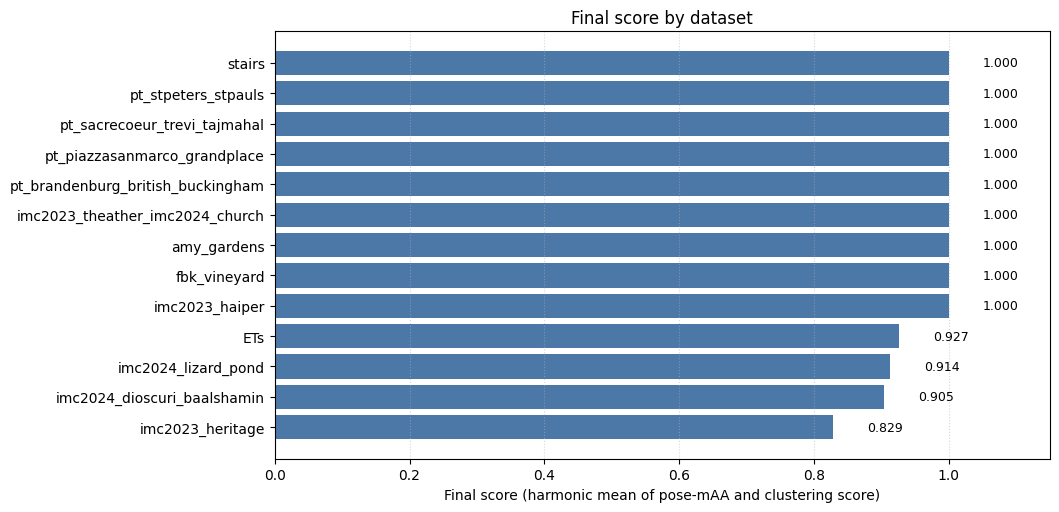

In [9]:
# --- Presentation scoreboard (clearly labeled) ---
import matplotlib.pyplot as plt

SUCCESS_POSE_COVERAGE_MIN = 0.30  # adjust for your slide narrative
TOPK_DATASETS = 3


def pose_coverage_for_dataset(ds: str) -> tuple[float, int, int]:
    keys = sorted(all_images_by_dataset.get(ds, set()))
    n_total = len(keys)
    n_pose = sum(pred_centers.get((ds, k)) is not None for k in keys)
    cov = (n_pose / n_total) if n_total else 0.0
    return cov, n_pose, n_total


rows = []
for ds in datasets:
    cov, n_pose, n_total = pose_coverage_for_dataset(ds)
    n_clusters = len([c for c in pred_clusters_by_dataset.get(ds, {}) if c != OUTLIERS_LABEL])
    rows.append(
        {
            "dataset": ds,
            "pose_coverage": cov,
            "n_pose": n_pose,
            "n_images": n_total,
            "n_pred_clusters": n_clusters,
        }
    )

present_df = pd.DataFrame(rows).merge(scores_df, on="dataset", how="left")
display(present_df.sort_values("final_score", ascending=False))

official_mean = float(present_df["final_score"].mean()) if len(present_df) else 0.0
success_df = present_df[present_df["pose_coverage"] >= SUCCESS_POSE_COVERAGE_MIN]
success_mean = float(success_df["final_score"].mean()) if len(success_df) else 0.0
topk = min(int(TOPK_DATASETS), len(present_df))
topk_mean = (
    float(present_df.nlargest(topk, "final_score")["final_score"].mean()) if topk else 0.0
)

print("\n=== Scoreboard ===")
print(f"Official mean final score (all datasets): {official_mean:.6f}")
print(
    f"Success-only mean (pose_coverage >= {SUCCESS_POSE_COVERAGE_MIN:.2f}; datasets={len(success_df)}): "
    f"{success_mean:.6f}"
)
print(f"Top-{topk} mean by final_score: {topk_mean:.6f}")

# --- Bar chart: final score per dataset ---
plot_df = present_df.sort_values("final_score", ascending=True)
fig_h = max(2.5, 0.35 * len(plot_df) + 1.0)
plt.figure(figsize=(10, fig_h))
plt.barh(plot_df["dataset"], plot_df["final_score"], color="#4C78A8")
plt.xlabel("Final score (harmonic mean of pose-mAA and clustering score)")
plt.title("Final score by dataset")

max_score = float(plot_df["final_score"].max()) if len(plot_df) else 0.0
x_pad = max(0.02, max_score * 0.05)
for i, v in enumerate(plot_df["final_score"].tolist()):
    plt.text(float(v) + x_pad, i, f"{float(v):.3f}", va="center", fontsize=9)

plt.xlim(0.0, max(0.05, max_score * 1.15))
plt.grid(axis="x", linestyle=":", alpha=0.5)
plt.show()
